# The Diverse Representation Canonical Interval Forest (DrCIF)

DrCIF \[1\] is an interval-based classifier: it makes time series bag-of-features
tractable by extracting summary features from random intervals of the series rather
than the whole series, and builds a forest of decision trees over those features. It
extends the Canonical Interval Forest (CIF) \[2\], which in turn extends the Time
Series Forest (TSF) \[3\], and is one of the four components of HIVE-COTE 2.0 \[1\].
The "diverse representation" part is that intervals are drawn not just from the raw
series, but also from its first-order differences and its periodogram.

This notebook covers how the algorithm works, fitting and evaluating it, digging into
a fitted model (including reproducing one of its trees by hand), the temporal
importance curves it can produce, its main parameters, and a note on runtime.

## 1. How DrCIF works

To build each of the `n_estimators` trees:

1. Make three views (representations) of every training series: the **base series**,
   its **first-order differences**, and its **periodogram**.
2. From each representation, sample a set of **random intervals** (random position and
   length; the number of intervals scales with the square root of the representation's
   length).
3. Summarise every interval with a fixed set of **attributes**. The candidate pool has
   29: the 22 [catch22](../../transformations/catch22.ipynb) features plus the mean,
   standard deviation, slope, median, interquartile range, min and max. Each tree
   randomly subsamples `att_subsample_size` (default 10) of the 29, so trees look at
   different summaries as well as different intervals.
4. Concatenate everything into one feature vector per series and fit an ordinary
   decision tree on it.

To predict, each tree transforms the new series with **its own** intervals and
attributes and votes; DrCIF averages the tree probability estimates. The randomness in
interval positions, interval lengths, representations and attribute subsets is what
gives the forest its diversity.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from aeon.classification.interval_based import DrCIFClassifier
from aeon.datasets import load_arrow_head

X_train, y_train = load_arrow_head(split="train")
X_test, y_test = load_arrow_head(split="test")
print("train:", X_train.shape, " test:", X_test.shape)
print("classes:", np.unique(y_train))

train: (36, 1, 251)  test: (175, 1, 251)
classes: ['0' '1' '2']


We use the ArrowHead dataset: three classes of arrowhead shape, converted to
univariate series of length 251. One example of each class:

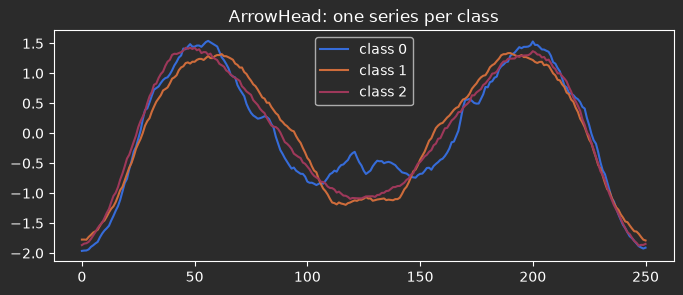

In [2]:
fig, ax = plt.subplots(figsize=(8, 3))
for cls in np.unique(y_train):
    ax.plot(X_train[y_train == cls][0, 0], label=f"class {cls}")
ax.legend()
ax.set_title("ArrowHead: one series per class")
plt.show()

## 2. The three representations

The base series captures shape in the time domain. The first-order differences
emphasise local slope and high-frequency behaviour. The periodogram gives a frequency
domain view, so periodic structure that is spread across the whole series can be
picked up by a single interval. An interval that is uninformative in one view can be
discriminative in another, which is why DrCIF samples intervals from all three:

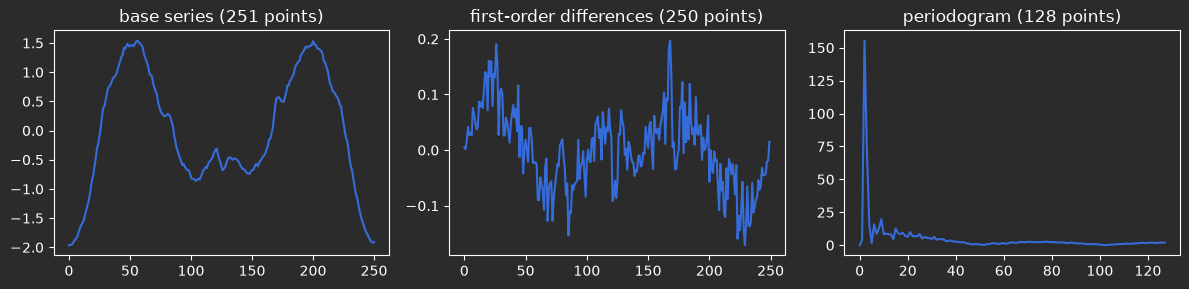

In [3]:
from aeon.transformations.collection import PeriodogramTransformer
from aeon.utils.numba.general import first_order_differences_3d

representations = [
    ("base series", X_train),
    ("first-order differences", first_order_differences_3d(X_train)),
    ("periodogram", PeriodogramTransformer().fit_transform(X_train)),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, (name, rep) in zip(axes, representations):
    ax.plot(rep[0, 0])
    ax.set_title(f"{name} ({rep.shape[2]} points)")
plt.tight_layout()
plt.show()

## 3. Fitting and evaluating

DrCIF is used like any aeon classifier. We also fit a Time Series Forest — the
ancestor which uses a single representation and only three summary statistics (mean,
standard deviation, slope) per interval — with the same number of trees, to see what
the extra representations and catch22 attributes buy on this problem:

In [4]:
from aeon.classification.interval_based import TimeSeriesForestClassifier

drcif = DrCIFClassifier(n_estimators=50, random_state=0)
start = time.perf_counter()
drcif.fit(X_train, y_train)
fit_time = time.perf_counter() - start
drcif_acc = drcif.score(X_test, y_test)

tsf = TimeSeriesForestClassifier(n_estimators=50, random_state=0)
tsf.fit(X_train, y_train)
tsf_acc = tsf.score(X_test, y_test)

print(f"DrCIF: test accuracy {drcif_acc:.3f}  (fit took {fit_time:.2f} s)")
print(f"TSF:   test accuracy {tsf_acc:.3f}")

DrCIF: test accuracy 0.766  (fit took 3.45 s)
TSF:   test accuracy 0.737


## 4. Inside a fitted model: reproducing a tree by hand

A fitted DrCIF stores, for every tree, one fitted interval transformer per
representation in `intervals_`. Each transformer records the intervals that tree drew
and the attributes it subsampled. Fitting a small forest and inspecting the first
tree shows exactly what it looks at:

In [5]:
small = DrCIFClassifier(n_estimators=5, random_state=0)
small.fit(X_train, y_train)

rep_names = ["base", "differences", "periodogram"]
for name, t in zip(rep_names, small.intervals_[0]):
    n_c22 = len(t.features[0].features)
    stats = [f.__name__ for f in t.features[1:]]
    print(f"{name}: {t.n_intervals} intervals, " f"{n_c22} catch22 features + {stats}")
print("total intervals for this tree:", small.total_intervals_)

base: 9 intervals, 8 catch22 features + ['row_slope', 'row_numba_max']
differences: 9 intervals, 7 catch22 features + ['row_slope', 'row_iqr', 'row_numba_min']
periodogram: 7 intervals, 8 catch22 features + ['row_numba_min', 'row_numba_max']
total intervals for this tree: 25


Tree 0 sampled 10 of the 29 candidate attributes (split between catch22 features
and summary statistics, differently for each representation's transformer).

There is nothing else hidden: applying those three fitted transformers to the three
representations and stacking the results reproduces exactly the feature matrix the
tree predicts from, and averaging all the trees' probability estimates reproduces the
ensemble output:

In [6]:
reps = [
    X_test,
    first_order_differences_3d(X_test),
    PeriodogramTransformer().fit_transform(X_test),
]

# rebuild tree 0's feature matrix and predict with its (plain sklearn) tree
parts = [t.transform(reps[r]) for r, t in enumerate(small.intervals_[0])]
features = np.nan_to_num(np.hstack(parts), False, 0, 0, 0)
print("tree 0 feature matrix:", features.shape)
tree0_by_hand = small.estimators_[0].predict(features)

tree0_library = small._predict_for_estimator(
    reps, small.estimators_[0], small.intervals_[0], predict_proba=False
)
print("tree 0 by hand == library:", np.array_equal(tree0_by_hand, tree0_library))

# the ensemble is just the mean of the trees' probability estimates
per_tree = [
    small._predict_for_estimator(
        reps, small.estimators_[i], small.intervals_[i], predict_proba=True
    )
    for i in range(len(small.estimators_))
]
print(
    "mean of tree probabilities == predict_proba:",
    np.allclose(np.mean(per_tree, axis=0), small.predict_proba(X_test)),
)

tree 0 feature matrix: (175, 250)
tree 0 by hand == library: True
mean of tree probabilities == predict_proba: True


## 5. Interpretability: temporal importance curves

Because every feature a tree splits on belongs to a known interval and attribute, the
information gain of the splits can be mapped back onto the time axis: for each
attribute, sum the gain of every split that used it over the time points its interval
covers. The result — introduced with CIF \[2\] — shows *where* in the series and
with *which* summaries the forest finds its discriminatory information:

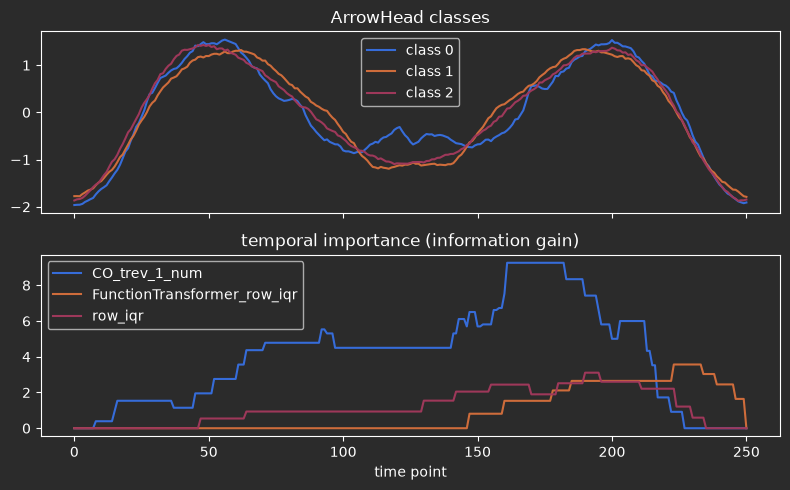

In [7]:
names, curves = drcif.temporal_importance_curves()

# plot the three attributes with the largest peak importance
top = np.argsort([c.max() for c in curves])[::-1][:3]
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
for cls in np.unique(y_train):
    axes[0].plot(X_train[y_train == cls][0, 0], label=f"class {cls}")
axes[0].legend()
axes[0].set_title("ArrowHead classes")
for i in top:
    axes[1].plot(curves[i], label=names[i])
axes[1].legend()
axes[1].set_title("temporal importance (information gain)")
axes[1].set_xlabel("time point")
plt.tight_layout()
plt.show()

## 6. Key parameters

- `n_estimators` (default 200): more trees rarely hurt accuracy but cost linear time.
- `att_subsample_size` (default 10): attributes sampled per tree from the pool of 29.
  Smaller values increase diversity and speed, at some risk to individual tree quality.
- `n_intervals` (default `"sqrt"`): intervals per representation per tree, as a
  function of the representation length.
- `min_interval_length` / `max_interval_length`: bounds on sampled interval sizes.
- `base_estimator`: the tree. Default is an entropy `DecisionTreeClassifier`; the
  `ContinuousIntervalTree` used in the original CIF paper is also supported.
- `time_limit_in_minutes`: contract the ensemble to a time budget instead of a fixed
  number of trees.
- `n_jobs`: trees are built and applied in parallel.

The accuracy/time trade-off for `n_estimators` on ArrowHead. Note that on a test set
of 175 cases each 0.006 of accuracy is a single case, so the differences between these
runs are noise — the reliable pattern is the linear growth in fit time, and that
ensemble variance stops improving results long before the default 200 trees on a
problem this small:

In [8]:
for n in (10, 25, 50, 100):
    clf = DrCIFClassifier(n_estimators=n, random_state=0)
    start = time.perf_counter()
    clf.fit(X_train, y_train)
    t = time.perf_counter() - start
    print(
        f"n_estimators={n:>3}: accuracy {clf.score(X_test, y_test):.3f}, "
        f"fit {t:5.2f} s"
    )

n_estimators= 10: accuracy 0.760, fit  0.62 s
n_estimators= 25: accuracy 0.737, fit  1.52 s
n_estimators= 50: accuracy 0.766, fit  3.02 s
n_estimators=100: accuracy 0.743, fit  6.23 s


## 7. Runtime

DrCIF's runtime is dominated by catch22 feature extraction — with the default
settings, well over half of both fit and predict time is spent computing catch22
attributes on intervals. aeon's catch22 is heavily optimised (shared intermediates,
batched FFTs, a compiled dispatch loop and faster feature algorithms); see the
[catch22 notebook](../../transformations/catch22.ipynb) for details and timings
against other implementations, including the original C library, which aeon's
implementation outperforms several times over.

## 8. References

\[1\] Middlehurst, M., Large, J., Flynn, M., Lines, J., Bostrom, A., & Bagnall, A.
(2021). HIVE-COTE 2.0: a new meta ensemble for time series classification. Machine
Learning, 110(11), 3211-3243.

\[2\] Middlehurst, M., Large, J., & Bagnall, A. (2020). The Canonical Interval
Forest (CIF) classifier for time series classification. IEEE International Conference
on Big Data, 188-195.

\[3\] Deng, H., Runger, G., Tuv, E., & Vladimir, M. (2013). A time series forest for
classification and feature extraction. Information Sciences, 239, 142-153.

\[4\] Lubba, C. H., Sethi, S. S., Knaute, P., Schultz, S. R., Fulcher, B. D., &
Jones, N. S. (2019). catch22: CAnonical Time-series CHaracteristics. Data Mining and
Knowledge Discovery, 33(6), 1821-1852.